# ex01) 데이터를 활용하여 이진분류 모델 설계 (유방암 데이터)

> **한 줄 요약** : 층을 아무리 바꿔도 안 되던 모델이, **activation(relu) + optimizer(adam)** 만 바꾸니 0.55 → 0.86 으로 올랐다.

## 오늘의 흐름
| 단계 | 내용 |
|---|---|
| 1 | 퍼셉트론 / MLP 개념 정리 |
| 2 | 유방암 데이터 불러오기 & 탐색 (X, y 분리 → train/test 분할) |
| 3 | 신경망 설계 (model1 : sigmoid + SGD) |
| 4 | 층 구조만 바꿔서 비교 (model2) → **효과 없음** |
| 5 | activation + optimizer 변경 (model3 : relu + adam) → **성능 급상승** |

## 꼭 기억할 키워드
`퍼셉트론` `MLP` `활성화 함수` `이진분류(units=1 + sigmoid)` `binary_crossentropy` `기울기 손실` `relu` `adam`

## 이진분류 출력층 공식
```python
model.add(Dense(units = 1, activation = 'sigmoid'))
model.compile(loss = 'binary_crossentropy', ...)
```


# 1. 오늘의 목표

- sklearn에서 제공하는 **유방암 데이터**를 활용하여 **이진분류 모델** 만들어 보기
- **MLP(Multi Layer Perceptron)** 의 개념에 대해 알아보기
- **퍼셉트론(Perceptron)** 에 대해 알아보기
- **활성화 함수**의 역할에 대해 알아보기

> 최종적으로 "종양이 **악성(malignant)** 인가 **양성(benign)** 인가"를 맞히는 모델을 만든다.


## 2. 퍼셉트론 (Perceptron)

**퍼셉트론 = 선형함수(y = wx + b) + 활성화 함수(activation)**

```
입력 x ──(가중치 w를 곱하고 b를 더함)──> 선형계산 ──> 활성화 함수 ──> 출력
```

- 데이터가 전달되기 위해 특정 자극(**역치**) 이상이 될 때만 데이터를 전달하도록 고안된 방법
  - 신경세포(뉴런)가 충분히 자극받았을 때만 신호를 넘기는 것을 흉내낸 것
- 사람처럼 생각하고 판단할 수 있도록 도움을 주기 위해 **활성화 함수**를 사용
- 퍼셉트론을 활용하여 데이터를 분석하고 전달하여 최종적인 예측값을 계산한다

> 코드에서 `Dense(units = 64)` 의 **units = 퍼셉트론(뉴런) 개수**


## 3. MLP (Multi Layer Perceptron, 다층 퍼셉트론)

- 단층 퍼셉트론의 차원 수를 확장시켜 **여러 개의 층**으로 구성하는 신경망 방법
- 단층일 경우 복잡한 데이터나 **비선형 문제**에 반응하지 못하는 상황이 발생
  → 여러 개의 층을 쌓아 문제를 해결하도록 만든 방법

```
입력층  →  중간층(은닉층) 여러 개  →  출력층
```

| 구분 | 역할 |
|---|---|
| 입력층 (InputLayer) | 데이터 한 개의 **모양(shape)** 을 알려줌 |
| 중간층 (Dense) | 실제로 특징을 학습하는 층, 여러 개 쌓음 |
| 출력층 (Dense) | 최종 예측값을 뱉는 층, **목적에 따라 구조가 정해짐** |


### 3-1. MLP의 특징 (장점 & 주의점)

**장점**
- 하나의 선형모델로 해결하지 못하는 문제를 해결할 수 있다
- 여러 상황이나 복잡한 데이터에 대응할 수 있다
- 단층에 비해 **성능 개선의 가능성이 높다**

**주의점** ⚠️
- 단층에 비해 **학습 시간이 오래 걸릴 수 있다**
- 모델이 복잡해지면 **과대적합(Overfitting)** 이 일어나기 쉬우므로 너무 많은 층을 사용해서는 안 된다


In [1]:
# 데이터를 다룰 수 있는 도구 불러오기
import numpy as np              # 수치 계산 / 배열
import pandas as pd             # 표 형태 데이터 다루기
import matplotlib.pyplot as plt # 학습 결과 그래프 그리기


In [2]:
# sklearn에서 제공하는 유방암 데이터셋 도구 불러오기
from sklearn.datasets import load_breast_cancer

# 데이터 불러오기 (인터넷 없이 바로 사용 가능한 내장 데이터)
data = load_breast_cancer()


In [3]:
# 불러온 데이터는 딕셔너리 형태로 여러가지 정보를 가지고 있어서
# 우리가 필요한 데이터를 뽑아서 사용해야 한다
data


{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]]),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0

In [4]:
# 딕셔너리 형태의 데이터에서 key값들을 뽑아내보기
data.keys()

# [key 설명]
# data          : 문제 데이터(입력 특성)  -> X
# target        : 정답 데이터(Label)      -> y
# frame         : 데이터프레임 유무
# target_names  : 정답 데이터의 이름       (malignant=악성, benign=양성)
# DESCR         : 데이터 설명(통계치)
# feature_names : 문제 데이터의 이름 (컬럼명)


dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [5]:
# 데이터를 사용하기 위해 문제 데이터와 정답 데이터를 뽑아보기
X = data['data']    # 문제 (30개의 특성)
y = data['target']  # 정답 (0 = 악성 / 1 = 양성)


In [6]:
# 데이터 크기 확인 (shape 확인은 항상 첫 번째로!)
print(X.shape)  # (569, 30)
print(y.shape)  # (569,)

# 데이터 개수 : 569개
# 컬럼의 개수 (특성의 수) : 30개
# → 나중에 InputLayer에 넣을 shape는 데이터 개수(569)가 아니라 (30,) 이다!


(569, 30)
(569,)


In [7]:
# 문제 데이터의 컬럼명(특성 이름) 확인
data['feature_names']

# radius(반지름), texture(질감), perimeter(둘레), area(넓이) ... 총 30개
# ※ area는 값이 수백~수천인데 smoothness는 0.1 수준 → 컬럼마다 값의 범위 차이가 아주 크다 (뒤에서 문제가 됨)


array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

In [8]:
# 정답 데이터의 이름 확인
data['target_names']

# array(['malignant', 'benign'])
# 0 = malignant(악성 종양) / 1 = benign(양성 종양)
# → 정답이 2가지이므로 '이진분류' 문제


array(['malignant', 'benign'], dtype='<U9')

In [9]:
# sklearn이나 tensorflow에서 제공하는 데이터셋은 누군가 이미 학습하기 좋은 형태로 가공을 마친 데이터
# 이기 때문에 따로 전처리 작업을 할 필요가 없다.
# 실제 데이터를 활용할 때는 꼭 전처리 작업을 해야만 성능적인 측면에서 좋은 결과를 얻을 수 있다.
# 문제 데이터와 정답 데이터를 활용하여 학습을 진행해보자.

# 학습용 데이터(train) / 평가용 데이터(test) 분할 진행
from sklearn.model_selection import train_test_split

# test_size = 0.3   : 전체의 30%를 평가용으로 사용
# random_state = 5  : 분할 결과를 고정 (다시 실행해도 같게 나눠짐 → 성능 비교가 공정해짐)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.3, random_state = 5)


In [10]:
# 데이터 크기 확인
print(X_train.shape)  # (398, 30) → 학습용 문제
print(X_test.shape)   # (171, 30) → 평가용 문제
print(y_train.shape)  # (398,)    → 학습용 정답
print(y_test.shape)   # (171,)    → 평가용 정답

# [데이터 분할 확인 방법]
# 1) 문제 데이터와 정답 데이터의 '개수'가 서로 같은지 확인 (398 vs 398 / 171 vs 171)
# 2) 사용하는 '컬럼의 수'가 학습용과 평가용이 같은지 확인 (30 vs 30)


(398, 30)
(171, 30)
(398,)
(171,)


## 4. 신경망 쌓기

- sklearn에서 제공한 유방암 데이터를 사용하기 위해 **이진분류 모델**을 직접 구성해보기
- **MLP 형식**으로 다층 구조의 신경망을 쌓아보기

**신경망 만드는 순서 (항상 동일)**
1. 뼈대 생성 `Sequential()`
2. 입력층 `InputLayer`
3. 중간층 `Dense` (여러 개)
4. 출력층 `Dense`
5. 학습방법 설정 `compile()`
6. 학습 `fit()`


In [11]:
# 신경망을 쌓기 위한 도구 불러오기
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import InputLayer

# Sequential  : 뼈대를 쌓는 도구 (층을 순서대로 차곡차곡 쌓겠다는 뜻)
# Dense       : 중간층과 출력층을 쌓는 도구 (앞 층의 모든 뉴런과 연결 = 전결합층)
# InputLayer  : 입력층을 쌓는 도구 중 하나


In [12]:
# ===== model1 : sigmoid + SGD (기준 모델) =====

# 1. 뼈대 생성
model1 = Sequential()

# 2. 입력층 쌓기
# 입력할 '데이터 1개'의 크기 설정 → 30개의 컬럼을 가진 1차원 데이터
# ※ 데이터 개수(398)는 적지 않는다!
model1.add(InputLayer(shape = (30,)))

# 3. 중간층(은닉층) 쌓기
# 여러 개의 층을 쌓아 사용하는 MLP 구조 - 다양한 상황이나 복잡한 데이터에 잘 반응하도록
model1.add(Dense(units = 64,  activation = 'sigmoid'))
model1.add(Dense(units = 128, activation = 'sigmoid'))
model1.add(Dense(units = 64,  activation = 'sigmoid'))
# units      : 퍼셉트론(뉴런)의 개수  →  퍼셉트론 = 선형모델 + 활성화 함수
# activation : 사람처럼 생각할 수 있도록 도와주는 함수
#              역치 이상의 결과값이 올 때만 다음 층으로 넘길 수 있도록 설정

# 4. 출력층 쌓기 ★이진분류 핵심★
# 모델의 사용 목적은 악성인지 양성인지 판단하는 '이진분류'
# 이진분류의 출력층 : units = 1 / activation = 'sigmoid'
#   → sigmoid가 0~1 사이의 '확률' 하나를 뱉고, 0.5보다 크면 1(양성)로 판단
model1.add(Dense(units = 1 , activation = 'sigmoid' ))


### 4-1. 중간층 쌓을 때의 경험적인 방법 (Tip)

1. `units`의 개수는 **2의 제곱수**를 사용하는 것이 성능적인 측면에서 유리할 가능성이 있다
   - ex) 16, 32, 64, 128, 256, 512 ...
2. `units`의 개수를 **항아리 모양**으로 설정하는 것이 유리할 가능성이 있다
   - 처음에는 적은 숫자 / 중간에 큰 숫자 / 마지막에 적은 숫자
   - ex) 128 → 256 → 512 → 256 → 128

> ⚠️ **절대적인 규칙이 아니다.** 반드시 성능을 비교해서 가장 좋은 성능이 나오는 모델을 찾아야 한다.


In [13]:
# 학습방법 및 평가방법 설정 (compile)

# loss      : 오차 계산 방법 - 모델의 사용 목적에 따라 다르게 사용
#   회귀       : MSE (mean_squared_error)
#   분류       : 크로스 엔트로피 (cross entropy)
#     - 이진분류 : binary_crossentropy
#     - 다중분류 : categorical_crossentropy
# optimizer : 오차를 줄일 수 있는 방법 설정 (SGD, Adam ...)
# metrics   : 사람이 보기 위한 평가지표 설정

model1.compile(
    loss = 'binary_crossentropy',  # 이진분류이므로 binary
    optimizer = 'SGD',             # 확률적 경사하강법 (가장 기본)
    metrics = ['accuracy']         # 정확도 사용
)


In [14]:
# 학습 진행
his1 = model1.fit(
    X_train, y_train,        # 문제, 정답
    epochs = 80,             # 전체 데이터를 80번 반복 학습
    validation_split = 0.2,  # 학습용의 20%를 검증용으로 떼어놓고 매 epoch마다 채점
)

# his1 : 학습 과정(정확도/오차 기록)이 담긴 History 객체 → 아래에서 그래프로 그린다
# accuracy = 훈련 정확도 / val_accuracy = 검증 정확도

# [결과] accuracy 약 0.638 / val_accuracy 약 0.550
# → 정제된 데이터인데도 성능이 매우 낮다. 심지어 값이 거의 움직이지 않는다 (학습이 안 됨)


Epoch 1/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.4214 - loss: 0.7131 - val_accuracy: 0.5500 - val_loss: 0.6895
Epoch 2/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6384 - loss: 0.6720 - val_accuracy: 0.5500 - val_loss: 0.6883
Epoch 3/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6384 - loss: 0.6595 - val_accuracy: 0.5500 - val_loss: 0.6923
Epoch 4/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6384 - loss: 0.6556 - val_accuracy: 0.5500 - val_loss: 0.6958
Epoch 5/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6384 - loss: 0.6541 - val_accuracy: 0.5500 - val_loss: 0.6992
Epoch 6/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6384 - loss: 0.6541 - val_accuracy: 0.5500 - val_loss: 0.6994
Epoch 7/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6384 - loss: 0.6528 - val_accuracy: 0.5500 - val_loss: 0.7000
Epoch 8/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6384 - loss: 0.6526 - val_accuracy: 0.5500 - v

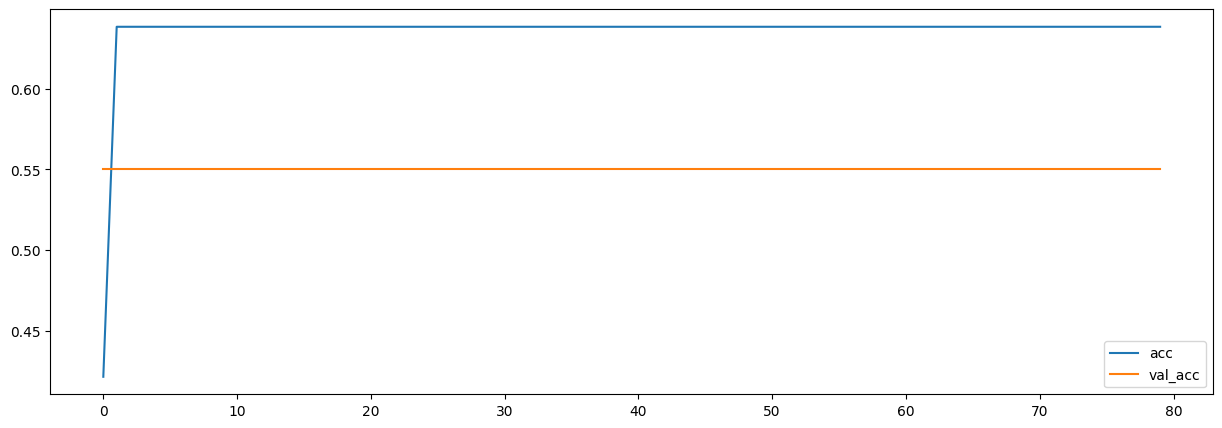

In [15]:
# 학습 결과 시각화
plt.figure(figsize = (15,5))
plt.plot(his1.history['accuracy'],     label = 'acc')      # 훈련 정확도
plt.plot(his1.history['val_accuracy'], label = 'val_acc')  # 검증 정확도
plt.legend()
plt.show()

# [보는 법]
# 선이 계속 평평하다 → 학습 자체가 진행되지 않고 있다는 신호
# acc↑ 인데 val_acc↓ → 과대적합(Overfitting)


### 4-2. 실습 : 구조를 바꿔서 성능 비교하기

- 중간층의 **퍼셉트론 개수나 층의 개수**를 조절하여 학습한 후 성능을 비교해보기
- `epochs`의 수는 동일하게 **80번**으로 고정 (조건을 하나만 바꿔야 공정한 비교가 된다)

| 모델 | 중간층 구조 | activation | optimizer |
|---|---|---|---|
| model1 | 64 - 128 - 64 | sigmoid | SGD |
| **model2** | **128 - 64 - 128** | sigmoid | SGD |


In [16]:
# (이미 위에서 불러왔지만 복습 겸 다시 불러오기)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import InputLayer


In [17]:
# ===== model2 : 중간층 구조만 바꿔보기 (128 - 64 - 128) =====
model2 = Sequential()

# 입력층 - 데이터 1개의 크기는 그대로 (30,)
model2.add(InputLayer(shape = (30,)))

# 중간층 - model1(64-128-64)과 반대로 배치해서 구조의 영향을 확인
model2.add(Dense(units = 128, activation = 'sigmoid'))
model2.add(Dense(units = 64,  activation = 'sigmoid'))
model2.add(Dense(units = 128, activation = 'sigmoid'))

# 출력층 - 이진분류이므로 units=1, sigmoid 고정
model2.add(Dense(units = 1 , activation = 'sigmoid' ))


In [18]:
# 학습방법 설정 - model1과 완전히 동일하게 (구조 변화만 비교하기 위해)
model2.compile(
    loss = 'binary_crossentropy',
    optimizer = 'SGD',
    metrics = ['accuracy'] # 정확도 사용
)


In [19]:
# 학습 진행 - epochs도 80으로 동일
his1 = model2.fit(
    X_train, y_train,
    epochs = 80,
    validation_split = 0.2,
)

# ⚠️ 주의 : model1의 기록이 담겨있던 his1 변수를 그대로 덮어쓰고 있다.
#           비교하려면 his2 처럼 다른 이름으로 저장하는 것이 좋다.

# [결과] accuracy 약 0.638 / val_accuracy 약 0.550
# → model1과 거의 똑같다. 즉 '층 구조'는 이번 문제의 원인이 아니었다.


Epoch 1/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.6384 - loss: 0.6566 - val_accuracy: 0.5500 - val_loss: 0.6949
Epoch 2/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6384 - loss: 0.6533 - val_accuracy: 0.5500 - val_loss: 0.6979
Epoch 3/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6384 - loss: 0.6518 - val_accuracy: 0.5500 - val_loss: 0.7003
Epoch 4/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6384 - loss: 0.6520 - val_accuracy: 0.5500 - val_loss: 0.6987
Epoch 5/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6384 - loss: 0.6508 - val_accuracy: 0.5500 - val_loss: 0.7042
Epoch 6/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6384 - loss: 0.6514 - val_accuracy: 0.5500 - val_loss: 0.7060
Epoch 7/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6384 - loss: 0.6510 - val_accuracy: 0.5500 - val_loss: 0.7022
Epoch 8/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6384 - loss: 0.6512 - val_accuracy: 0.5500 - v

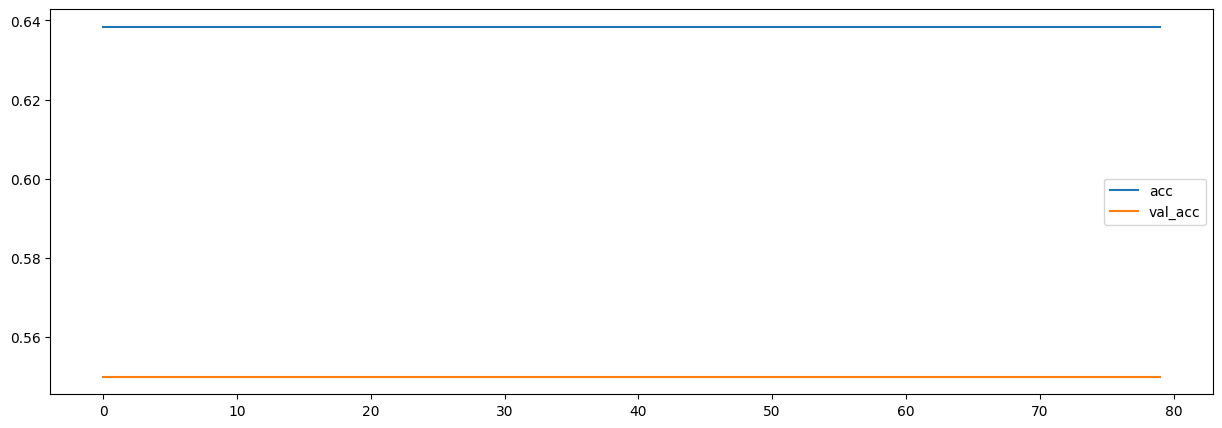

In [20]:
# 결과 시각화 (여기서의 his1은 바로 위에서 덮어쓴 model2의 기록)
plt.figure(figsize = (15,5))
plt.plot(his1.history['accuracy'],     label = 'acc')
plt.plot(his1.history['val_accuracy'], label = 'val_acc')
plt.legend()
plt.show()


### 4-3. 결과 정리 (1차)

**model1 / model2 모두 : accuracy 약 0.638 / val_accuracy 약 0.550**

- 우리가 사용한 데이터는 사용하기 편하도록 **정제가 잘 되어 있는 데이터**인데도
- 성능이 많이 **낮게** 나온 것을 확인할 수 있음 (찍는 것과 큰 차이가 없는 수준)
- 성능을 개선하기 위해 퍼셉트론의 개수나 층의 형태를 변경해서 학습해봤지만 **성능은 여전히 비슷**했다
- 👉 결국 성능을 개선하려면 **근본적인 문제**를 해결할 필요가 있다
  - 데이터가 부족하지는 않은지?
  - 특성의 수가 적어서 모델이 단순하지는 않은지?
  - **오차를 찾아나갈 때(학습 방법에) 문제가 있지는 않은지?** ← 이번의 진짜 원인


## 5. 활성화 함수와 최적화 함수를 변경하여 학습 진행

- `activation = 'relu'` / `optimizer = 'adam'`
- **층 구조(64-128-64)와 epochs(80)는 model1과 완전히 동일하게 두고**, 두 가지만 바꿔서 비교한다

| 모델 | 중간층 구조 | activation | optimizer |
|---|---|---|---|
| model1 | 64 - 128 - 64 | sigmoid | SGD |
| **model3** | 64 - 128 - 64 | **relu** | **adam** |


In [21]:
# ===== model3 : relu + adam =====
model3 = Sequential()

# 입력층 쌓기
model3.add(InputLayer(shape = (30,)))

# 중간층 쌓기 - 구조는 model1과 동일! activation만 relu로 변경
# relu : 음수는 0, 양수는 그대로 통과 → 미분값이 1이라 기울기 손실이 거의 없다
model3.add(Dense(units = 64,  activation = 'relu'))
model3.add(Dense(units = 128, activation = 'relu'))
model3.add(Dense(units = 64,  activation = 'relu'))

# 출력층 쌓기
# ※ 출력층은 여전히 sigmoid! 이진분류의 '확률'을 뱉어야 하기 때문
#    (중간층의 activation과 출력층의 activation은 역할이 다르다)
model3.add(Dense(units = 1 , activation = 'sigmoid'))


In [22]:
# 학습방법 및 평가방법 설정
model3.compile(
    loss = 'binary_crossentropy',
    optimizer = 'adam',        # SGD → adam 으로 변경 (방향 + 학습률을 동시에 보정)
    metrics = ['accuracy']
)


In [23]:
# 학습
his3 = model3.fit(
    X_train, y_train,
    epochs = 80,
    validation_split = 0.2,
)

# [결과] accuracy 약 0.91 / val_accuracy 약 0.86
# → 층 구조는 그대로인데 activation + optimizer만 바꿨더니 0.55 → 0.86 으로 급상승!


Epoch 1/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - accuracy: 0.5252 - loss: 32.2898 - val_accuracy: 0.5625 - val_loss: 6.6079
Epoch 2/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.5409 - loss: 4.6487 - val_accuracy: 0.6625 - val_loss: 3.7885
Epoch 3/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6667 - loss: 2.3819 - val_accuracy: 0.9000 - val_loss: 0.5442
Epoch 4/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7987 - loss: 1.4650 - val_accuracy: 0.9125 - val_loss: 0.4251
Epoch 5/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8899 - loss: 0.6349 - val_accuracy: 0.8750 - val_loss: 0.4730
Epoch 6/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8994 - loss: 0.4020 - val_accuracy: 0.9000 - val_loss: 0.3469
Epoch 7/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8805 - loss: 0.3355 - val_accuracy: 0.8625 - val_loss: 0.3132
Epoch 8/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8459 - loss: 0.4939 - val_accuracy: 0.8250 - 

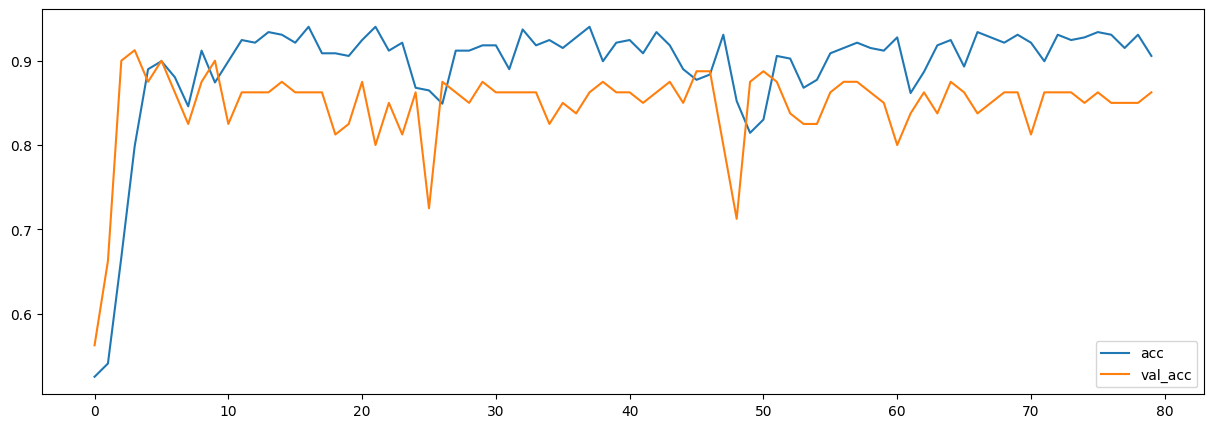

In [24]:
# 결과 시각화
plt.figure(figsize = (15,5))
plt.plot(his3.history['accuracy'],     label = 'acc')
plt.plot(his3.history['val_accuracy'], label = 'val_acc')
plt.legend()
plt.show()

# 평평했던 model1/model2와 달리, 선이 확실하게 우상향하는 것을 볼 수 있다 = 학습이 되고 있다


## 6. 결과 정리 (2차) — 성능이 갑자기 좋아진 이유

| 모델 | 구조 | activation | optimizer | val_accuracy |
|---|---|---|---|:---:|
| model1 | 64-128-64 | sigmoid | SGD | 약 **0.55** |
| model2 | 128-64-128 | sigmoid | SGD | 약 **0.55** |
| **model3** | 64-128-64 | **relu** | **adam** | 약 **0.86** ⬆ |

- 활성화 함수(activation)와 최적화 함수(optimizer)를 바꿨더니 성능이 눈에 띄게 늘어난 것을 확인
- **왜 좋아졌을까?**
  1. **sigmoid → relu**
     - sigmoid는 미분값이 최대 0.25라, 층을 지날수록 기울기가 0에 가까워지는 **기울기 손실(Vanishing Gradient)** 발생
     - relu는 양수 구간의 미분값이 1이라 기울기가 그대로 전달됨 → 앞쪽 층까지 학습이 된다
  2. **SGD → adam**
     - SGD는 이전 방향도, 학습률도 조정하지 않아 지그재그로 헤매며 아주 느리게 이동
     - adam은 **방향(momentum) + 학습률(adagrad)** 을 동시에 보정 → 훨씬 빠르고 안정적으로 최적점에 도달

> 💡 **핵심 교훈** : 층을 더 쌓거나 뉴런 수를 늘리는 것보다
> **활성화 함수와 최적화 함수를 제대로 고르는 것**이 성능에 훨씬 큰 영향을 준다.

**추가로 더 해볼 수 있는 것**
- 이 데이터는 컬럼마다 값의 범위 차이가 매우 크다 (`area`는 수천, `smoothness`는 0.1 수준)
  → **StandardScaler로 스케일링**하면 sigmoid + SGD 조합도 성능이 크게 올라간다
